# Job Market Analytics Project

This notebook is part of my Data Analyst portfolio project.  
The goal is to clean and analyze job posting data collected from Google Search jobs.

The project includes:

- Basic data quality checks
- Data cleaning
- Feature engineering
- Duplicate handling
- Salary extraction
- Junior/Intern skills analysis
- Remote job analysis
- Basic salary analysis
- Exporting the processed dataset

The main business question is:

**What skills, seniority levels, remote opportunities, and salary patterns can be found in job market data?**

## 1. Import Libraries

First, I import the main Python libraries used for data analysis and visualization.

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import ast
import sqlite3

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 2. Load Dataset

The dataset is loaded from the raw data folder. This keeps the original file separate from the cleaned/processed version.

In [36]:
df = pd.read_csv('../data/raw/gsearch_jobs.csv')

df.head()

,Unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,thumbnail,posted_at,schedule_type,work_from_home,salary,search_term,date_time,search_location,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,0,0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,True,101K–143K a year,data analyst,2023-08-04 03:00:13.797776,United States,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,18 hours ago,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
3,3,3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,NaN,12 hours ago,Contractor,True,15–25 an hour,data analyst,2023-08-04 03:00:13.797776,United States,NaN,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']"
4,4,4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,NaN,90K–110K a year,data analyst,2023-08-04 03:00:13.797776,United States,NaN,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']"


## 3. Initial Data Quality Checks

Before cleaning the dataset, I check the shape, columns, data types, missing values, duplicates, and common location values.

In [37]:
print('Shape:', df.shape)
print('Columns:')
print(df.columns)
print('Duplicated rows:', df.duplicated().sum())
print('Missing values:')
print(df.isna().sum().sort_values(ascending=False))

Shape: (61953, 27)
Columns:
Index(['Unnamed: 0', 'index', 'title', 'company_name', 'location', 'via',
       'description', 'extensions', 'job_id', 'thumbnail', 'posted_at',
       'schedule_type', 'work_from_home', 'salary', 'search_term', 'date_time',
       'search_location', 'commute_time', 'salary_pay', 'salary_rate',
       'salary_avg', 'salary_min', 'salary_max', 'salary_hourly',
       'salary_yearly', 'salary_standardized', 'description_tokens'],
      dtype='str')
Duplicated rows: 0
Missing values:
commute_time           61953
salary_yearly          57884
salary_hourly          56053
salary_max             52441
salary_min             52441
salary                 51865
salary_standardized    51865
salary_avg             51865
salary_rate            51865
salary_pay             51865
work_from_home         33973
thumbnail              23759
schedule_type            246
posted_at                190
location                  37
via                        9
Unnamed: 0           

In [38]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 61953 entries, 0 to 61952
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           61953 non-null  int64  
 1   index                61953 non-null  int64  
 2   title                61953 non-null  str    
 3   company_name         61953 non-null  str    
 4   location             61916 non-null  str    
 5   via                  61944 non-null  str    
 6   description          61953 non-null  str    
 7   extensions           61953 non-null  str    
 8   job_id               61953 non-null  str    
 9   thumbnail            38194 non-null  str    
 10  posted_at            61763 non-null  str    
 11  schedule_type        61707 non-null  str    
 12  work_from_home       27980 non-null  object 
 13  salary               10088 non-null  str    
 14  search_term          61953 non-null  str    
 15  date_time            61953 non-null  str    
 1

## 4. Helper Functions

I created separate helper functions to make the cleaning process easier to read and reuse.

In [39]:
FAKE_MISSING_VALUES = ['', ' ', 'nan', 'NaN', 'None', 'none', 'null', 'NULL']


def strip_text_columns(df):
    """
    Remove extra spaces from all text columns.
    Location is also converted to title case for better consistency.
    """

    df = df.copy()

    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    if 'location' in df.columns:
        df['location'] = df['location'].str.title()

    return df


def get_seniority(title):
    """
    Extract a simple seniority level from the job title.
    """

    title = str(title).lower()

    if 'intern' in title:
        return 'Intern'
    elif 'junior' in title or 'entry level' in title:
        return 'Junior'
    elif 'senior' in title:
        return 'Senior'
    elif 'lead' in title or 'manager' in title:
        return 'Lead'
    elif 'mid' in title:
        return 'Mid'
    else:
        return 'Not Specified'


def extract_salary(s):
    """
    Extract an estimated yearly salary from a salary text field.
    The function tries to handle hourly, monthly, weekly, and daily salaries.
    """

    if pd.isna(s):
        return np.nan

    s = str(s).lower()
    s = s.replace('$', '').replace('€', '').replace(',', '').replace('k', '000')
    nums = re.findall(r'\d+', s)

    if not nums:
        return np.nan

    nums = list(map(int, nums))
    salary = nums[0] if len(nums) == 1 else sum(nums[:2]) / 2

    if 'hour' in s:
        salary *= 2080
    elif 'month' in s:
        salary *= 12
    elif 'week' in s:
        salary *= 52
    elif 'day' in s:
        salary *= 5 * 52

    return salary


def safe_parse_tokens(x):
    """
    Convert description_tokens from string format to list format.
    If the value is missing or cannot be parsed, return an empty list.
    """
    
    if isinstance(x, list):
        return x

    if pd.isna(x):
        return []

    try:
        return ast.literal_eval(x)
    except:
        return []

## 5. Cleaning Pipeline

The cleaning function performs the main data preparation steps:

- Drops unnecessary columns
- Replaces fake missing values with real NaN values
- Removes rows without job titles
- Strips text columns
- Fills important categorical missing values with `Unknown`
- Standardizes remote location values

In [40]:
def cleaning_jobs(df):
    """
    Clean job dataset:
    - remove unnecessary columns
    - handle missing values
    - standardize text columns
    """

    df = df.copy()

    df = df.drop(columns=[
        'Unnamed: 0','commute_time','search_location','salary_avg','salary_min','salary_max','search_term',
        'thumbnail','salary_pay', 'salary_rate', 'salary_hourly','salary_yearly'
    ], errors='ignore')


    df = df.replace(FAKE_MISSING_VALUES, np.nan)

    df = df.dropna(subset=['title'])
    
    df = strip_text_columns(df)

    fill_unknown_cols = ['company_name', 'location', 'via', 'work_from_home', 'schedule_type']

    for col in fill_unknown_cols:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')

    df['location'] = df['location'].replace({
        'Anywhere' : 'Remote',
        'Workfromhome' : 'Remote'
    })

    return df

## 6. Feature Engineering

In this step, I create new useful columns:

- `seniority_level`: estimated from the job title
- `remote_job`: shows whether a job looks remote
- `salary_estimate`: extracted from the text salary column
- `final_salary`: combines standardized salary and estimated salary

I also remove duplicate job postings based on title, company, and location.

In [41]:
def data_features(df):
    """
    Create useful analytical features:
    - seniority level
    - remote job flag
    - salary estimate
    - final salary
    - remove duplicated job postings
    """

    df = df.copy()

    df['seniority_level'] = df['title'].apply(get_seniority)

    df['remote_job'] = (
        df['location'].str.lower().str.contains('remote', na=False) |
        df['title'].str.lower().str.contains('remote', na=False) |
        df['work_from_home'].astype(str).str.lower().isin(['yes', 'remote', '1', 'true'])
    )

    df['salary_estimate'] = df['salary'].apply(extract_salary)

    df['final_salary'] = df['salary_standardized']
    df['final_salary'] = df['final_salary'].fillna(df['salary_estimate'])

    duplicates_before = df.duplicated(subset=['title', 'company_name', 'location']).sum()
    df = df.drop_duplicates(subset=['title', 'company_name', 'location'])
    duplicates_after = df.duplicated(subset=['title', 'company_name', 'location']).sum()

    print(f"""
    Duplicates before cleaning: {duplicates_before}
    Duplicates after cleaning: {duplicates_after}
    """)
    
    return df

## 7. Apply Cleaning and Feature Engineering

Now I apply both main functions to create the final analytical dataset.

In [42]:
df_clean = cleaning_jobs(df)
df_features = data_features(df_clean)

df_features.head(10)

/var/folders/2w/lrkzkm553f1gh6c5c1m1qwqm0000gn/T/ipykernel_7179/306469990.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:



    Duplicates before cleaning: 21204
    Duplicates after cleaning: 0
    


,index,title,company_name,location,via,description,extensions,job_id,posted_at,schedule_type,work_from_home,salary,date_time,salary_standardized,description_tokens,seniority_level,remote_job,salary_estimate,final_salary
0,0,Data Analyst,Meta,Remote,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,15 hours ago,Full-time,True,101K–143K a year,2023-08-04 03:00:13.797776,122000.0,"['tableau', 'r', 'python', 'sql']",Not Specified,True,122000.0,122000.0
1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,12 hours ago,Full-time,Unknown,NaN,2023-08-04 03:00:13.797776,NaN,[],Not Specified,False,NaN,NaN
2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, Ks",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,18 hours ago,Full-time,Unknown,NaN,2023-08-04 03:00:13.797776,NaN,['sql'],Not Specified,False,NaN,NaN
3,3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Remote,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,12 hours ago,Contractor,True,15–25 an hour,2023-08-04 03:00:13.797776,41600.0,"['powerpoint', 'excel', 'power_bi']",Not Specified,True,41600.0,41600.0
4,4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,7 hours ago,Contractor,Unknown,90K–110K a year,2023-08-04 03:00:13.797776,100000.0,"['powerpoint', 'excel', 'outlook', 'word']",Not Specified,False,100000.0,100000.0
5,5,Data Analyst,Flint Hills Resources,"Wichita, Ks",via Jora,Your Job\n\nFlint Hills Resources is seeking a...,"['20 hours ago', 'Full-time', 'Health insuranc...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,20 hours ago,Full-time,Unknown,NaN,2023-08-04 03:00:13.797776,NaN,"['power_bi', 'aws', 'excel', 'sql', 'mysql', '...",Not Specified,False,NaN,NaN
6,6,Data Analyst (Model Validation),Swedbank,Remote,via JobTeaser,"Are you passionate about Credit Risk, Data Ana...","['17 hours ago', 'Work from home', 'Full-time'...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgKE1vZGVsIF...,17 hours ago,Full-time,True,NaN,2023-08-04 03:00:13.797776,NaN,"['python', 'sas', 'sql', 'spss']",Not Specified,True,NaN,NaN
7,7,Data Analyst,AEG,United States,via IT Job Depot,"In order to be considered for this role, after...","['8 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,8 hours ago,Full-time,Unknown,NaN,2023-08-04 03:00:13.797776,NaN,"['power_bi', 'tableau', 'jira', 'snowflake', '...",Not Specified,False,NaN,NaN
8,8,IT Financial Data Analyst Lead,Progressive,Remote,via Jobgether,"This a Full Remote job, the offer is available...","['7 hours ago', 'Work from home', 'Full-time',...",eyJqb2JfdGl0bGUiOiJJVCBGaW5hbmNpYWwgRGF0YSBBbm...,7 hours ago,Full-time,True,NaN,2023-08-04 03:00:13.797776,NaN,[],Lead,True,NaN,NaN
9,9,Data Analyst,Chloeta,"Oklahoma City, Ok",via ZipRecruiter,Job Summary: The Data Analyst oversees data pr...,"['21 hours ago', 'Full-time', 'Health insuranc...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,21 hours ago,Full-time,Unknown,NaN,2023-08-04 03:00:13.797776,NaN,"['r', 'python']",Not Specified,False,NaN,NaN


## 8. Check Processed Dataset

After cleaning, I check the dataset again to make sure the transformations worked correctly.

In [43]:
print('Processed shape:', df_features.shape)

print('Missing values percentage:')
missing = df_features.isna().mean() * 100
missing.sort_values(ascending=False).head(15)

Processed shape: (40749, 19)
Missing values percentage:


final_salary           83.373825
salary_estimate        83.373825
salary_standardized    83.373825
salary                 83.373825
posted_at               0.112886
work_from_home          0.000000
remote_job              0.000000
seniority_level         0.000000
description_tokens      0.000000
date_time               0.000000
index                   0.000000
title                   0.000000
job_id                  0.000000
extensions              0.000000
description             0.000000
dtype: float64

## 9. Seniority Level Distribution

This chart shows how many job postings belong to each seniority level. This is important because the dataset may contain more senior jobs than junior jobs, which can affect conclusions about skills and salary.

In [44]:
df_features['seniority_level'].value_counts()

seniority_level
Not Specified    32061
Senior            4959
Lead              2282
Intern             760
Junior             586
Mid                101
Name: count, dtype: int64

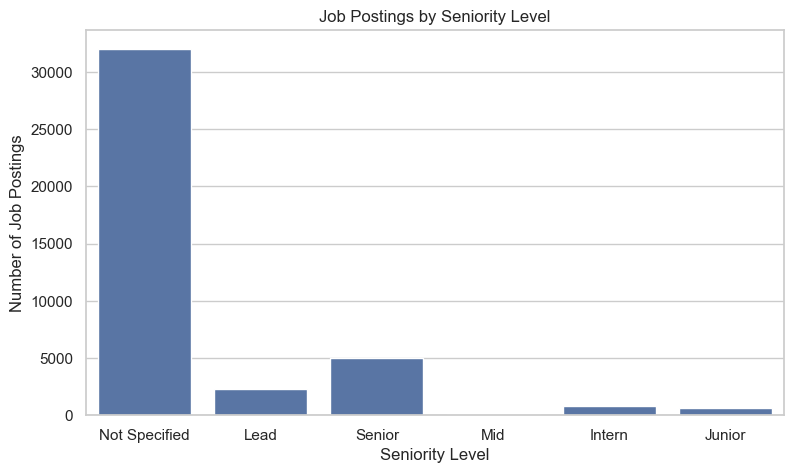

In [45]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_features,
    x='seniority_level',
)
plt.title('Job Postings by Seniority Level')
plt.xlabel('Seniority Level')
plt.ylabel('Number of Job Postings')
plt.show()

### Observation

The dataset contains many jobs where seniority is not clearly specified in the title. This means that some roles may actually be junior, mid, or senior, but the title does not explicitly say it.

## 10. Remote Jobs by Seniority Level

Here I compare seniority level with the remote job flag. This helps to understand whether remote work appears more often for specific levels.

In [46]:
remote_by_seniority = pd.crosstab(
    df_features['seniority_level'],
    df_features['remote_job'],
    normalize='index'
) * 100

remote_by_seniority

remote_job,False,True
seniority_level,,
Intern,72.631579,27.368421
Junior,53.924915,46.075085
Lead,59.772130,40.227870
Mid,58.415842,41.584158
Not Specified,50.238608,49.761392
Senior,62.734422,37.265578


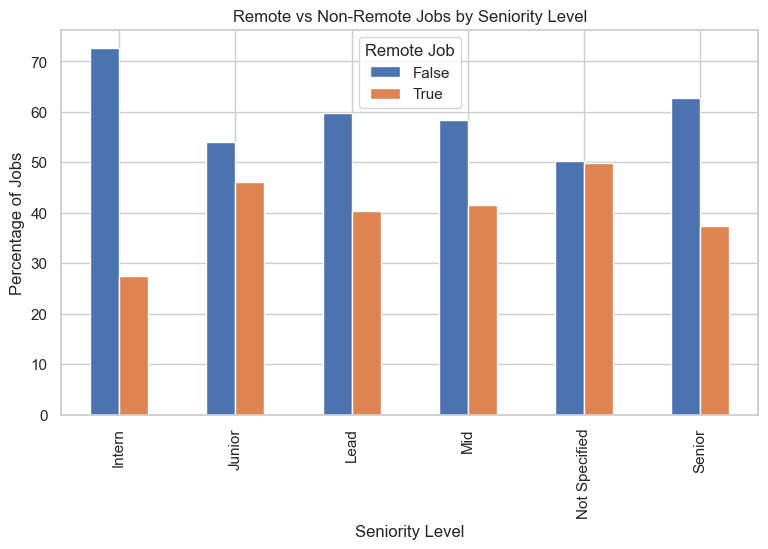

In [47]:
remote_by_seniority.plot(kind='bar', figsize=(9, 5))
plt.title('Remote vs Non-Remote Jobs by Seniority Level')
plt.xlabel('Seniority Level')
plt.ylabel('Percentage of Jobs')
plt.legend(title='Remote Job')
plt.show()

### Observation

Senior, Lead, Mid, and Junior roles may appear to have more remote opportunities than Intern roles. However, this should be interpreted carefully because the dataset may have incomplete information about remote status.

## 11. Most Popular Skills for Junior and Intern Roles

The `description_tokens` column contains extracted skills or keywords from job descriptions. I focus on Junior and Intern roles because this is the most relevant group for an entry-level data analyst job search.

In [48]:

df_features['description_tokens'] = df_features['description_tokens'].apply(safe_parse_tokens)

skills_for_junior = (
    df_features[df_features['seniority_level'].isin(['Junior', 'Intern'])]['description_tokens']
    .explode()
    .value_counts()
    .head(20)
)

skills_for_junior

description_tokens
excel          597
sql            565
python         455
power_bi       425
tableau        361
r              229
powerpoint     158
word           140
java            98
sas             77
javascript      75
c++             68
spreadsheet     61
azure           53
docker          51
spark           50
aws             49
outlook         46
sap             42
go              41
Name: count, dtype: int64

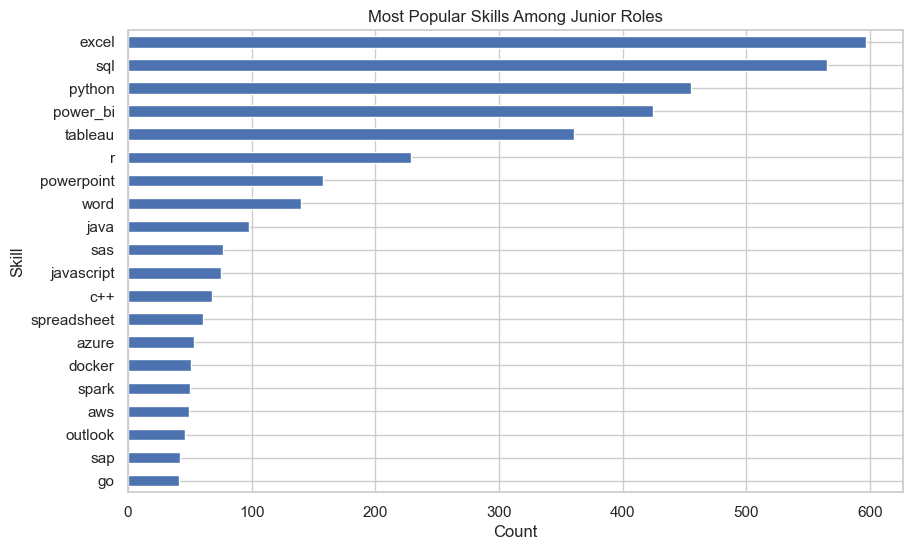

In [49]:
skills_for_junior.plot(kind='barh', figsize=(10, 6))
plt.xlabel('Count')
plt.ylabel('Skill')
plt.title('Most Popular Skills Among Junior Roles')
plt.gca().invert_yaxis()
plt.show()

### Observation

For starting roles, skills such as Excel, SQL, Python, and visualization tools appear often. This suggests that these are important technical skills for junior data-related positions.

## 12. Salary Analysis

In this section, I analyze the `final_salary` column. Because salary data can contain missing values and outliers, I first create a filtered salary dataset.

In [50]:
salary_df = df_features[df_features['final_salary'].notna()].copy()

salary_df[['salary', 'salary_standardized', 'salary_estimate', 'final_salary']].head()

,salary,salary_standardized,salary_estimate,final_salary
0,101K–143K a year,122000.0,122000.0,122000.0
3,15–25 an hour,41600.0,41600.0,41600.0
4,90K–110K a year,100000.0,100000.0,100000.0
10,54.00–60.52 an hour,119100.8,56160.0,119100.8
14,90K–130K a year,110000.0,110000.0,110000.0


In [51]:
salary_df['final_salary'].describe()

count      6775.000000
mean      94259.189422
std       44349.123596
min       15080.000000
25%       63440.000000
50%       90000.000000
75%      119600.000000
max      624000.000000
Name: final_salary, dtype: float64

### Salary Outlier Check

Very high salary values may be real in some cases, but they can also be parsing errors or unusual job postings. Here I check salaries above 300,000.

In [52]:
salary_df[salary_df['final_salary'] > 300000][[
    'title', 'company_name', 'location', 'salary', 'salary_standardized', 'salary_estimate', 'final_salary'
]].head(20)

,title,company_name,location,salary,salary_standardized,salary_estimate,final_salary
3472,Quantitative Researcher - Fundamental Equities,Non-Disclosed,United States,450K–650K a year,550000.0,550000.0,550000.0
8776,Sr. Data & Reporting Analyst,PCS Retirement,Remote,19K–850K a year,434500.0,434500.0,434500.0
15714,Experienced Looker BI Data Analyst Consultant ...,Upwork,Remote,150–200 an hour,364000.0,364000.0,364000.0
22608,Freelance Data Analyst,Upwork,Remote,100–500 an hour,624000.0,624000.0,624000.0
22699,Looking for a EXPERT Equity Research Analyst -...,Upwork,Remote,200–250 an hour,468000.0,468000.0,468000.0
26273,Lead Quantitative Researcher - Equity Stat Arb,Algo Capital Group,United States,250K–700K a year,475000.0,475000.0,475000.0
44830,Analyze census data,Upwork,Remote,100–200 an hour,312000.0,312000.0,312000.0
45593,Cluster Analysis Expert,Upwork,Remote,50–250 an hour,312000.0,312000.0,312000.0
45815,Consulting from Data buyer,Upwork,Remote,150–400 an hour,572000.0,572000.0,572000.0
46243,Data Analyst for Ecommerce and Marketing Agency,Upwork,Remote,10–300 an hour,322400.0,322400.0,322400.0


For the main salary analysis, I remove very high outliers above 300,000 to make averages easier to interpret.

In [53]:
salary_filtered = salary_df[salary_df['final_salary'] <= 300000].copy()

salary_by_seniority = salary_filtered.groupby('seniority_level')['final_salary'].agg(['mean', 'median', 'count'])
salary_by_seniority.sort_values('mean', ascending=False)

,mean,median,count
seniority_level,,,
Lead,120160.301270,122720.0,315
Senior,113317.029074,106810.0,594
Not Specified,91180.922261,85000.0,5682
Mid,89918.813333,80267.2,15
Junior,71294.346197,69680.0,71
Intern,51257.012500,47522.8,88


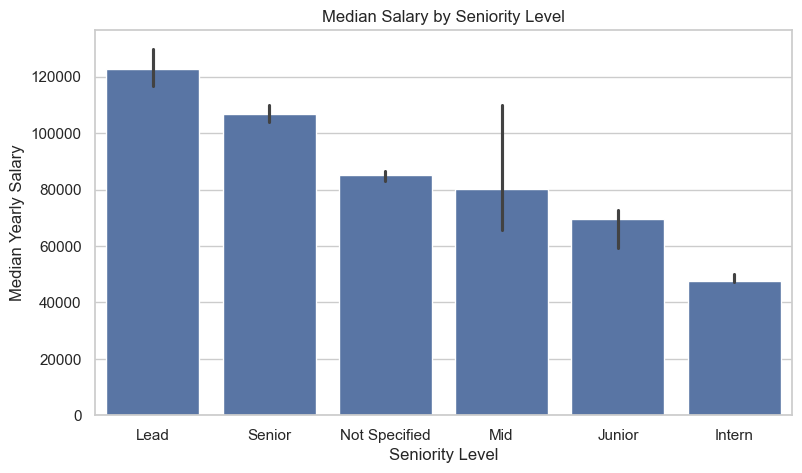

In [54]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=salary_filtered,
    x='seniority_level',
    y='final_salary',
    estimator=np.median,
    order=salary_filtered.groupby('seniority_level')['final_salary'].median().sort_values(ascending=False).index
)
plt.title('Median Salary by Seniority Level')
plt.xlabel('Seniority Level')
plt.ylabel('Median Yearly Salary')
plt.show()

### Observation

In general, higher seniority levels tend to have higher salaries. However, the `Not Specified` group should not be treated as one clear level because it may include mixed junior, mid, and senior roles.

## 13. Schedule Type and Salary

This section checks average salary by schedule type.

In [55]:
salary_filtered.groupby('schedule_type')['final_salary'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False)

,mean,median,count
schedule_type,,,
Full-time and Temp work,119245.900000,106080.0000,8
Full-time and Contractor,103932.461290,102500.0000,31
Full-time,101967.426309,96500.0000,3033
Contractor,91904.221878,83200.0000,2258
Unknown,82619.790625,75738.0875,24
Temp work,82080.000000,75000.0000,15
Part-time and Full-time,74000.000000,74000.0000,2
"Part-time, Contractor, and Temp work",82338.636944,73840.0000,18
Part-time,81429.383784,72800.0000,74


## 14. Top Companies and Job Titles

Here I check which companies and job titles appear most often in the dataset.

In [56]:
df_features['company_name'].value_counts().head(15)

company_name
Upwork                 5709
Walmart                1077
Talentify.io            944
Dice                    556
EDWARD JONES            485
iSay                    286
Insight Global          242
Cox Communications      219
Corporate               173
vmysmartpros            173
Centene Corporation     130
Jobs via Dice           122
R1 RCM                  114
Leidos                  112
Sam's Club              105
Name: count, dtype: int64

In [57]:
df_features['title'].value_counts().head(15)

title
Data Analyst                     3393
Senior Data Analyst              1000
Data Scientist                    570
Survey Data Analyst               338
Data Analyst II                   327
Business Data Analyst             300
Data Engineer                     272
Lead Data Analyst                 226
Business Intelligence Analyst     224
Sr. Data Analyst                  156
Business Analyst                  151
Financial Data Analyst            147
Marketing Data Analyst            137
Junior Data Analyst               135
Data Analyst III                  132
Name: count, dtype: int64

## 15. Export Processed Dataset

Finally, I export the cleaned and feature-engineered dataset to the processed data folder. This file can be used later for SQL analysis, Tableau dashboards, or machine learning.

In [90]:
df_features.to_csv('../data/processed/gsearch_jobs_processed.csv', index=False)

tableau_df = df_features.drop(columns=[
    'description',
    'description_tokens'
], errors='ignore')

tableau_df.to_csv(
    '../data/processed/gsearch_jobs_tableau.csv',
    index=False,
    encoding='utf-8'
)

sql_df = df_features[[
    'title',
    'company_name',
    'location',
    'via',
    'schedule_type',
    'work_from_home',
    'seniority_level',
    'remote_job',
    'final_salary'
]].copy()

conn = sqlite3.connect('../sql/job_analysis.db')
sql_df.to_sql('job_posting', conn, if_exists='replace', index=False)
conn.close()

print('Processed dataset exported successfully.')

Processed dataset exported successfully.


## Machine Learning: Salary Prediction

As an additional step, a simple machine learning regression model was created to predict estimated yearly salaries based on structured job posting features.

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


features = ['location', 'via','schedule_type',
    'seniority_level','remote_job','final_salary']

df_ml = df_features[features].copy()

df_ml['final_salary'] = df_ml['final_salary'].fillna(
    df_ml['final_salary'].median()
)

df_ml = pd.get_dummies(
    df_ml,
    columns=['location', 'via','schedule_type','seniority_level'],
    drop_first=True
)

y = df_ml['final_salary']

X = df_ml.drop('final_salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=8
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, y_pred))
print('R2 Score:', r2_score(y_test, y_pred))



MAE: 6200.328425718694
R2 Score: 0.04729378973139986


### Features Used
The model used the following features:

- Location
- Job posting platform (`via`)
- Schedule type
- Seniority level
- Remote work indicator


### Model
A `RandomForestRegressor` from Scikit-learn was used for the prediction task.

### Evaluation Metrics
The model was evaluated using:

- Mean Absolute Error (MAE)
- R² Score

### Results
- MAE: ~6200
- R² Score: ~0.05

The relatively low R² score indicates that salary prediction is difficult using only a small set of structured features. Salary levels are influenced by many additional factors not available in the dataset, such as specific technical skills, years of experience, industry, and geographic region.

The purpose of this section was not to build a production-level salary prediction system, but rather to demonstrate a basic end-to-end machine learning workflow:
- preprocessing
- feature encoding
- train/test split
- model training
- prediction
- evaluation

# Final Conclusions

The goal of the analysis was to identify trends in the job market related to:
- remote work
- salary distribution
- hiring activity
- seniority levels
- company demand

## Data Cleaning

Several preprocessing steps were performed before analysis:

- Removed duplicates and unnecessary columns
- Handled missing values
- Standardized text columns
- Created seniority categories from job titles
- Built a remote job indicator using multiple signals
- Estimated salaries from raw salary information

## Key Insights

### Remote Work
A significant portion of job postings were identified as remote positions. Remote jobs were detected using information from:
- job title
- location
- work-from-home indicators

### Seniority Distribution
Most job postings belonged to mid-level and senior-level categories, while internship and junior opportunities represented a smaller share of the dataset.

### Salary Distribution
Salary values showed a heavily skewed distribution with several high-paying outliers. Most estimated salaries were concentrated in mid-range salary bands.

### Hiring Activity
A small number of companies accounted for a large share of total job postings, suggesting concentrated hiring activity among major employers and staffing platforms.

### Geographic Trends
Certain locations dominated the dataset and appeared much more frequently than others, reflecting geographic concentration in the job market data.

## Tableau Dashboard

https://public.tableau.com/app/profile/semyon.sidorov/viz/JobAnalysis_17781033583570/Dashboard2

Interactive dashboards were created in Tableau to visualize:
- job market overview
- salary analysis
- remote work trends
- top hiring companies
- seniority distribution

The dashboards were designed to provide a simple business-oriented overview of the dataset and support exploratory analysis.